# 02. Framing Business Questions as Supervised and Unsupervised Tasks

Machine learning projects often fail before model fitting begins. The failure is usually not that the optimizer is weak or the feature matrix is too small. The failure is that the business question was translated into the wrong learning task.

This lecture focuses on that translation step. We will keep working in an account-operations setting, but instead of asking only whether a model predicts well, we will ask a stricter question: what exactly are we asking the model to produce, for whom, and in support of which decision?

That perspective aligns with a long-running theme in statistical learning: prediction problems are inseparable from the use context in which errors will matter (Breiman, 2001; Domingos, 2012). It also matches modern reminders that labels, reporting discipline, and deployment framing matter at least as much as whether we call a method "statistics" or "machine learning" (Bzdok et al., 2018; Van Calster et al., 2019).


## Learning Objectives

By the end of this lecture, you should be able to:

1. Translate an operational business question into a supervised or unsupervised learning task.
2. Define the unit of analysis, decision horizon, and target variable in a way that matches an actual decision.
3. Explain how regression, classification, ranking, and clustering can all emerge from the same underlying business problem.
4. Diagnose common task-framing mistakes before they become modeling mistakes.


In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "notebooks" / "_shared").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", None)


## 1. Task Framing Comes Before Model Choice

A useful abstract summary of supervised learning is

$$
f^* = \arg \min_f \; \mathbb{E}[L(Y, f(X))].
$$

The notation is compact, but the practical message is large. The analyst has to specify:

- what counts as the outcome $Y$,
- what information is available in $X$ at decision time,
- what loss function $L$ represents the organization's error costs, and
- what action will be taken once the model output arrives.

If those ingredients are vague, the project is vague. If they are mismatched, the project can be technically correct and operationally useless.

Breiman's distinction between explanatory and predictive cultures is helpful here, but for decision science we should go one step further: the right framing is the one that changes an action in a defensible way (Breiman, 2001).


### One Business Problem Can Become Several Different ML Tasks

| Business question | Valid ML framing | Typical output | Decision it supports |
|---|---|---|---|
| Which accounts will consume the most service effort next month? | Regression | Expected support hours | Staffing and workload planning |
| Which accounts are most likely to breach service commitments? | Binary classification | Probability of breach | Risk triage and proactive intervention |
| Which 100 accounts should a specialist team review first? | Ranking | Ordered priority list | Capacity-constrained outreach |
| Are there natural account types that need different default playbooks? | Clustering / unsupervised learning | Operational segments | Workflow design and differentiated service models |

The important idea is that none of these framings is automatically the "real" one. They answer related but distinct decision questions.


### Mathematical Spine: Targets, Actions, and Loss Functions

Task framing becomes clearer when we write down the **target space**, the **model output**, and the **loss or utility** attached to errors. Suppose an analyst observes features \(X\) and produces a score or decision rule \(s(X)\). Different machine-learning tasks correspond to different mathematical objects.

For **regression**, the target is continuous, \(Y \in \mathbb{R}\), and the model maps features into a numeric prediction:

$$
s : \mathcal{X} \to \mathbb{R}, \qquad \hat y = s(X).
$$

Typical losses are squared error and absolute error,

$$
L_{\text{sq}}(y, \hat y) = (y - \hat y)^2, \qquad L_{\text{abs}}(y, \hat y) = |y - \hat y|,
$$

which encode different ideas of operational pain.

For **classification**, the target is discrete, often binary, \(Y \in \{0,1\}\). The model often produces a score or estimated probability \(\hat p(X)\in[0,1]\), which is then converted into a decision with a threshold \(t\):

$$
\hat y(t) = \mathbf{1}[\hat p(X) \ge t].
$$

For **ranking**, the objective is to order units by a score and intervene only on the top part of the list. If capacity allows action on at most \(k\) units, then the deployed set is

$$
S_k = \{ i : s_i \text{ is among the top } k \text{ scores} \}.
$$

This is mathematically different from ordinary classification because the loss depends on scarce intervention capacity.

For **clustering**, there is no labeled \(Y\). We instead seek a partition of observations into groups \(C_1, \ldots, C_K\) such that units within a cluster are similar under some distance or objective. In k-means,

$$
\min_{C_1,\ldots,C_K} \sum_{k=1}^K \sum_{i \in C_k} \lVert x_i - \mu_k \rVert_2^2.
$$

The main lesson is that one business question can generate several mathematically distinct learning problems. Choosing among them means choosing which errors matter, which actions are feasible, and which objective the analyst is truly trying to optimize.

## 2. Synthetic Account-Operations Panel

We will build a synthetic monthly panel for a B2B software company. Each row is one account observed this month, together with outcomes realized over the next 30 days.

This simulation gives us a controlled environment for studying framing decisions. We can embed multiple latent account types, nonlinear operational pressure, and different target variables while still knowing the ground truth structure used to create the data.

Importantly, the simulation also includes hidden account-level friction that is **not** handed to the model directly. That keeps the exercise realistic: a well-framed task can produce strong decision support without producing unrealistically perfect prediction.


In [2]:
# Section focus: 2. Synthetic Account-Operations Panel.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


def modal_value(series):
    """Return the most common observed category for a column in the example data.
    
    Parameters
    ----------
    series : object
        One-dimensional pandas object whose distribution or most common value is being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the modal value calculation and reused by later cells.
    """
    mode = series.mode(dropna=True)
    return mode.iloc[0] if not mode.empty else np.nan


def make_one_hot_encoder():
    """Construct the one hot encoder helper used in the 02. Framing Business Questions as Supervised and Unsupervised Tasks workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def simulate_account_panel(n_accounts=950, months=12, random_state=2026):
    """Create a simulated account panel data set for the 02. Framing Business Questions as Supervised and Unsupervised Tasks case study.
    
    Parameters
    ----------
    n_accounts : object
        Number of account records to create for the simulated business setting.
    months : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    month_labels = pd.period_range("2025-01", periods=months, freq="M").astype(str)

    segments = [
        "Self-serve SMB",
        "Growth mid-market",
        "Complex enterprise",
        "Distressed high-risk",
    ]
    segment_probs = np.array([0.34, 0.29, 0.21, 0.16])

    segment_profiles = {
        "Self-serve SMB": {
            "log_revenue": 3.95,
            "seats_per_revenue": 1.45,
            "seat_noise": 20,
            "usage_mean": 0.46,
            "complexity_mean": 2.2,
            "training_mean": 0.78,
            "adoption_mean": 0.66,
            "incident_lambda": 0.35,
            "ticket_lambda": 1.4,
            "backlog_base": 1.0,
            "response_base": 55,
            "nps_base": 57,
            "support_base": 0.9,
            "growth_pressure": 0.02,
            "plan_tiers": ["Basic", "Growth"],
            "plan_probs": [0.70, 0.30],
            "industry_probs": [0.32, 0.30, 0.16, 0.22],
            "region_probs": [0.42, 0.28, 0.20, 0.10],
        },
        "Growth mid-market": {
            "log_revenue": 4.75,
            "seats_per_revenue": 2.35,
            "seat_noise": 45,
            "usage_mean": 0.63,
            "complexity_mean": 4.3,
            "training_mean": 0.69,
            "adoption_mean": 0.71,
            "incident_lambda": 0.6,
            "ticket_lambda": 3.0,
            "backlog_base": 3.0,
            "response_base": 75,
            "nps_base": 49,
            "support_base": 2.4,
            "growth_pressure": 0.05,
            "plan_tiers": ["Growth", "Premium"],
            "plan_probs": [0.64, 0.36],
            "industry_probs": [0.28, 0.24, 0.24, 0.24],
            "region_probs": [0.35, 0.25, 0.26, 0.14],
        },
        "Complex enterprise": {
            "log_revenue": 5.68,
            "seats_per_revenue": 3.10,
            "seat_noise": 85,
            "usage_mean": 0.72,
            "complexity_mean": 7.1,
            "training_mean": 0.58,
            "adoption_mean": 0.61,
            "incident_lambda": 0.9,
            "ticket_lambda": 5.0,
            "backlog_base": 5.5,
            "response_base": 105,
            "nps_base": 42,
            "support_base": 4.6,
            "growth_pressure": 0.03,
            "plan_tiers": ["Premium"],
            "plan_probs": [1.0],
            "industry_probs": [0.16, 0.18, 0.30, 0.36],
            "region_probs": [0.30, 0.27, 0.29, 0.14],
        },
        "Distressed high-risk": {
            "log_revenue": 5.00,
            "seats_per_revenue": 2.55,
            "seat_noise": 60,
            "usage_mean": 0.58,
            "complexity_mean": 6.3,
            "training_mean": 0.34,
            "adoption_mean": 0.38,
            "incident_lambda": 1.2,
            "ticket_lambda": 6.0,
            "backlog_base": 8.0,
            "response_base": 145,
            "nps_base": 28,
            "support_base": 5.6,
            "growth_pressure": 0.01,
            "plan_tiers": ["Growth", "Premium"],
            "plan_probs": [0.35, 0.65],
            "industry_probs": [0.18, 0.22, 0.26, 0.34],
            "region_probs": [0.26, 0.24, 0.33, 0.17],
        },
    }

    industries = ["SaaS", "Retail", "Fintech", "Healthcare"]
    regions = ["North America", "Europe", "APAC", "LATAM"]

    records = []

    for account_number in range(1, n_accounts + 1):
        segment = rng.choice(segments, p=segment_probs)
        profile = segment_profiles[segment]

        annual_revenue_k = float(np.exp(rng.normal(profile["log_revenue"], 0.42)))
        seat_count = int(
            np.clip(
                np.round(annual_revenue_k * profile["seats_per_revenue"] + rng.normal(0, profile["seat_noise"])),
                15,
                6000,
            )
        )
        contract_age_start = int(rng.integers(3, 48))
        industry = rng.choice(industries, p=profile["industry_probs"])
        region = rng.choice(regions, p=profile["region_probs"])
        plan_tier = rng.choice(profile["plan_tiers"], p=profile["plan_probs"])

        base_usage = np.clip(rng.normal(profile["usage_mean"], 0.10), 0.10, 0.98)
        base_complexity = np.clip(rng.normal(profile["complexity_mean"], 0.85), 1.0, 10.0)
        base_training = np.clip(rng.normal(profile["training_mean"], 0.08), 0.08, 0.98)
        base_adoption = np.clip(rng.normal(profile["adoption_mean"], 0.09), 0.05, 0.98)

        latent_escalation_risk = rng.normal(0, 1.0)
        renewal_pressure = rng.normal(0, 1.0)

        for month_index, month in enumerate(month_labels, start=1):
            seasonality = 0.45 * np.sin(2 * np.pi * month_index / 12)
            growth_shock = profile["growth_pressure"] * month_index

            usage_intensity = np.clip(base_usage + growth_shock + rng.normal(0, 0.04), 0.05, 0.99)
            integration_complexity = np.clip(base_complexity + rng.normal(0, 0.35), 1.0, 10.0)
            training_completion_rate = np.clip(
                base_training - 0.012 * month_index + rng.normal(0, 0.04),
                0.05,
                0.99,
            )
            feature_adoption_rate = np.clip(
                base_adoption + 0.015 * month_index + rng.normal(0, 0.05),
                0.05,
                0.99,
            )

            monthly_product_incidents = int(
                max(
                    0,
                    rng.poisson(
                        profile["incident_lambda"]
                        + 1.0 * max(usage_intensity - 0.78, 0)
                        + 0.20 * seasonality
                    ),
                )
            )

            prior_tickets_30d = int(
                max(
                    0,
                    rng.poisson(
                        profile["ticket_lambda"]
                        + 0.25 * monthly_product_incidents
                        + 0.40 * integration_complexity
                        + 2.8 * max(usage_intensity - 0.70, 0)
                    ),
                )
            )

            unresolved_backlog = max(
                0,
                profile["backlog_base"]
                + 0.45 * prior_tickets_30d
                + 0.60 * monthly_product_incidents
                + 1.0 * integration_complexity
                + 1.6 * max(latent_escalation_risk, 0)
                + rng.normal(0, 3.2),
            )

            avg_response_minutes_last90d = np.clip(
                profile["response_base"]
                + 2.8 * prior_tickets_30d
                + 6.5 * monthly_product_incidents
                + 0.50 * unresolved_backlog
                + 6.0 * max(renewal_pressure, 0)
                + rng.normal(0, 18),
                10,
                480,
            )

            nps = np.clip(
                profile["nps_base"]
                - 0.65 * prior_tickets_30d
                - 0.06 * avg_response_minutes_last90d
                + 10 * training_completion_rate
                + 7 * feature_adoption_rate
                - 2.4 * max(latent_escalation_risk, 0)
                + rng.normal(0, 5.0),
                1,
                99,
            )

            support_hours_next_30d = np.clip(
                profile["support_base"]
                + 0.005 * seat_count
                + 1.35 * monthly_product_incidents
                + 0.55 * prior_tickets_30d
                + 1.0 * integration_complexity
                + 0.018 * avg_response_minutes_last90d
                + 7 * max(usage_intensity - 0.80, 0)
                - 3.8 * training_completion_rate
                - 2.5 * feature_adoption_rate
                + 0.0008 * annual_revenue_k
                + 1.1 * max(latent_escalation_risk, 0)
                + 0.7 * max(renewal_pressure, 0)
                + rng.normal(0, 2.2),
                0.3,
                None,
            )

            breach_logit = (
                -3.7
                + 0.18 * monthly_product_incidents
                + 0.08 * prior_tickets_30d
                + 0.16 * integration_complexity
                + 0.010 * avg_response_minutes_last90d
                + 0.030 * unresolved_backlog
                - 1.3 * training_completion_rate
                - 0.9 * feature_adoption_rate
                - 0.020 * nps
                + 0.30 * (plan_tier == "Premium")
                + 0.45 * (segment == "Distressed high-risk")
                + 0.15 * seasonality
                + 0.55 * latent_escalation_risk
                + 0.35 * renewal_pressure
                + rng.normal(0, 0.70)
            )
            sla_breach_next_30d = int(rng.random() < sigmoid(breach_logit))

            records.append(
                {
                    "account_id": f"A{account_number:04d}",
                    "month": month,
                    "month_index": month_index,
                    "true_segment": segment,
                    "annual_revenue_k": annual_revenue_k,
                    "seat_count": seat_count,
                    "usage_intensity": usage_intensity,
                    "integration_complexity": integration_complexity,
                    "training_completion_rate": training_completion_rate,
                    "feature_adoption_rate": feature_adoption_rate,
                    "nps": nps,
                    "prior_tickets_30d": prior_tickets_30d,
                    "avg_response_minutes_last90d": avg_response_minutes_last90d,
                    "monthly_product_incidents": monthly_product_incidents,
                    "unresolved_backlog": unresolved_backlog,
                    "contract_age_months": contract_age_start + month_index,
                    "plan_tier": plan_tier,
                    "industry": industry,
                    "region": region,
                    "support_hours_next_30d": support_hours_next_30d,
                    "sla_breach_next_30d": sla_breach_next_30d,
                }
            )

    df = pd.DataFrame(records)
    rounded_columns = [
        "annual_revenue_k",
        "usage_intensity",
        "integration_complexity",
        "training_completion_rate",
        "feature_adoption_rate",
        "avg_response_minutes_last90d",
        "unresolved_backlog",
        "support_hours_next_30d",
    ]
    df[rounded_columns] = df[rounded_columns].round(3)
    return df


df = simulate_account_panel()

panel_overview = pd.DataFrame(
    [
        {"quantity": "Rows", "value": len(df), "interpretation": "Each row is one account-month."},
        {"quantity": "Accounts", "value": df["account_id"].nunique(), "interpretation": "Repeated over 12 monthly snapshots."},
        {"quantity": "Months", "value": df["month"].nunique(), "interpretation": "Decision-time panel indexed from month 1 to month 12."},
        {
            "quantity": "Mean next-month support hours",
            "value": round(df["support_hours_next_30d"].mean(), 2),
            "interpretation": "Regression target for expected service burden.",
        },
        {
            "quantity": "SLA breach prevalence",
            "value": round(df["sla_breach_next_30d"].mean(), 3),
            "interpretation": "Classification target rate for service failure risk.",
        },
    ]
)

smart_display(panel_overview)
smart_display(df.head(8))


,quantity,value,interpretation
0,Rows,11400.000000,Each row is one account-month.
1,Accounts,950.000000,Repeated over 12 monthly snapshots.
2,Months,12.000000,Decision-time panel indexed from month 1 to month 12.
3,Mean next-month support hours,12.420000,Regression target for expected service burden.
4,SLA breach prevalence,0.156000,Classification target rate for service failure risk.


,account_id,month,month_index,true_segment,annual_revenue_k,seat_count,usage_intensity,integration_complexity,training_completion_rate,feature_adoption_rate,nps,prior_tickets_30d,avg_response_minutes_last90d,monthly_product_incidents,unresolved_backlog,contract_age_months,plan_tier,industry,region,support_hours_next_30d,sla_breach_next_30d
0,A0001,2025-01,1,Self-serve SMB,57.457,45,0.507,2.029,0.725,0.720,61.984,1,71.007,0,2.775,7,Growth,Retail,APAC,0.711,0
1,A0001,2025-02,2,Self-serve SMB,57.457,45,0.502,2.444,0.689,0.764,58.619,5,64.012,0,8.708,8,Growth,Retail,APAC,4.672,0
2,A0001,2025-03,3,Self-serve SMB,57.457,45,0.525,1.683,0.784,0.800,65.760,3,93.737,0,2.412,9,Growth,Retail,APAC,0.321,0
3,A0001,2025-04,4,Self-serve SMB,57.457,45,0.570,1.871,0.725,0.849,61.654,0,38.221,0,1.916,10,Growth,Retail,APAC,0.300,0
4,A0001,2025-05,5,Self-serve SMB,57.457,45,0.642,1.765,0.712,0.739,61.217,2,79.627,1,8.672,11,Growth,Retail,APAC,1.397,1
5,A0001,2025-06,6,Self-serve SMB,57.457,45,0.671,1.721,0.692,0.838,62.302,6,48.966,0,0.468,12,Growth,Retail,APAC,7.387,0
6,A0001,2025-07,7,Self-serve SMB,57.457,45,0.588,1.606,0.600,0.828,66.825,3,75.390,0,6.435,13,Growth,Retail,APAC,0.300,0
7,A0001,2025-08,8,Self-serve SMB,57.457,45,0.626,1.963,0.732,0.790,61.352,1,53.457,0,7.816,14,Growth,Retail,APAC,2.740,0


The Synthetic Account-Operations Panel result matters when it changes the next move. The useful evidence is the part that changes model selection, diagnostics, thresholds, or governance limits.


,month,accounts,mean_support_hours,breach_rate
0,2025-01,950,11.910,0.167
1,2025-02,950,11.891,0.144
2,2025-03,950,12.174,0.155
3,2025-04,950,12.249,0.174
4,2025-05,950,12.268,0.145
5,2025-06,950,12.481,0.162
6,2025-07,950,12.452,0.157
7,2025-08,950,12.578,0.152
8,2025-09,950,12.551,0.157
9,2025-10,950,12.721,0.147


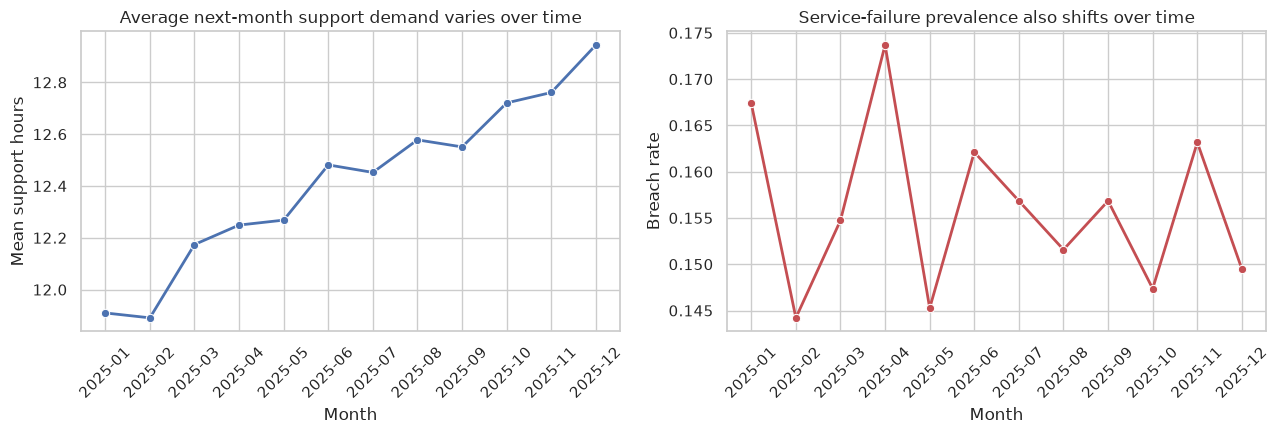

In [3]:
# Section focus: 2. Synthetic Account-Operations Panel.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

monthly_summary = (
    df.groupby("month", as_index=False)
    .agg(
        accounts=("account_id", "count"),
        mean_support_hours=("support_hours_next_30d", "mean"),
        breach_rate=("sla_breach_next_30d", "mean"),
    )
)

smart_display(monthly_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(
    data=monthly_summary,
    x="month",
    y="mean_support_hours",
    marker="o",
    linewidth=2.0,
    ax=axes[0],
)
axes[0].set_title("Average next-month support demand varies over time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean support hours")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_summary,
    x="month",
    y="breach_rate",
    marker="o",
    linewidth=2.0,
    color="#C44E52",
    ax=axes[1],
)
axes[1].set_title("Service-failure prevalence also shifts over time")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Breach rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Several framing lessons are already visible before any model is fit.

First, the unit is not "an account" in the abstract; it is an **account-month observed at decision time**. Second, the prediction horizon is explicit: outcomes occur over the next 30 days, not at some vague future endpoint. Third, the same panel can support multiple labels, each aligned to a different action.

This is why decision-science framing usually begins with the trio **unit, horizon, action**. Only after those are fixed does it make sense to debate model class, validation design, or deployment mechanics.


## 3. Translate the Raw Panel Into Concrete Task Definitions

We now turn one operational objective into several formal task definitions.

Suppose the customer-success organization says: **"We need to reduce service failures next month while using our specialist support team efficiently."** That statement still contains multiple possible ML problems.

The raw panel itself does not decide whether the project is a regression problem, classification problem, ranking problem, or segmentation problem. That choice comes from the operational action. A staffing team may care about expected workload, a specialist team may care about the top few accounts to review, and a product-operations team may care about recurring account types. The same account-month rows can therefore support several legitimate ML tasks.

The point of the exercise is to make that translation explicit before modeling begins. For each task we should name the unit, outcome horizon, target variable or structure, action capacity, and cost of a wrong decision. This keeps the notebook from treating machine learning as a library call and makes the framing step visible.


| Task framing | Formal target or output | Decision-time inputs allowed | Immediate action | Good first metric family |
|---|---|---|---|---|
| Regression | `support_hours_next_30d` | Features known by the end of this month | Forecast staffing burden and queue design | RMSE / MAE |
| Classification | `sla_breach_next_30d` | Same decision-time features | Flag accounts for proactive outreach | ROC AUC / PR AUC |
| Ranking | Ordered list from a score | Same features plus a prioritization score | Select top-$k$ accounts under limited capacity | Capture rate in top-$k$ |
| Clustering | Segment labels inferred from features | Features only, usually at a common snapshot date | Create differentiated service playbooks | Cohesion, separation, interpretability |

The raw data did not tell us which formulation to use. That choice comes from the operational question.


In [4]:
# Section focus: 3. Translate the Raw Panel Into Concrete Task Definitions.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

numeric_features = [
    "annual_revenue_k",
    "seat_count",
    "usage_intensity",
    "integration_complexity",
    "training_completion_rate",
    "feature_adoption_rate",
    "nps",
    "prior_tickets_30d",
    "avg_response_minutes_last90d",
    "monthly_product_incidents",
    "unresolved_backlog",
    "contract_age_months",
]
categorical_features = ["plan_tier", "industry", "region"]
feature_columns = numeric_features + categorical_features

train_mask = df["month_index"] <= 9
test_mask = df["month_index"] >= 10

X_train = df.loc[train_mask, feature_columns]
X_test = df.loc[test_mask, feature_columns]

y_train_reg = df.loc[train_mask, "support_hours_next_30d"]
y_test_reg = df.loc[test_mask, "support_hours_next_30d"]

y_train_clf = df.loc[train_mask, "sla_breach_next_30d"]
y_test_clf = df.loc[test_mask, "sla_breach_next_30d"]

split_summary = pd.DataFrame(
    [
        {
            "split": "Training",
            "rows": int(train_mask.sum()),
            "months": "2025-01 to 2025-09",
            "mean_support_hours": round(y_train_reg.mean(), 2),
            "breach_rate": round(y_train_clf.mean(), 3),
        },
        {
            "split": "Holdout",
            "rows": int(test_mask.sum()),
            "months": "2025-10 to 2025-12",
            "mean_support_hours": round(y_test_reg.mean(), 2),
            "breach_rate": round(y_test_clf.mean(), 3),
        },
    ]
)

smart_display(split_summary)


,split,rows,months,mean_support_hours,breach_rate
0,Training,8550,2025-01 to 2025-09,12.280,0.157
1,Holdout,2850,2025-10 to 2025-12,12.810,0.153


This output matters because the result has to support an operating decision. For Translate the Raw Panel Into Concrete Task Definitions, the result should tell us which cases are actionable, which are ambiguous, and where human review is needed. The implication is an operating policy with an investigation path.


## 4. Supervised Framing: Regression and Classification

We will start with two baseline supervised tasks built from the same feature set.

- A **regression model** predicts expected support hours next month.
- A **classification model** predicts the probability of an SLA breach next month.

Using the same features for both tasks is intentional. It helps isolate a central framing lesson: a different target changes both the metric and what the model output means and how a team can act on it.


,task,metric_1,value_1,metric_2,value_2
0,Regression,RMSE,2.261,MAE,1.803
1,Classification,ROC AUC,0.868,PR AUC,0.550


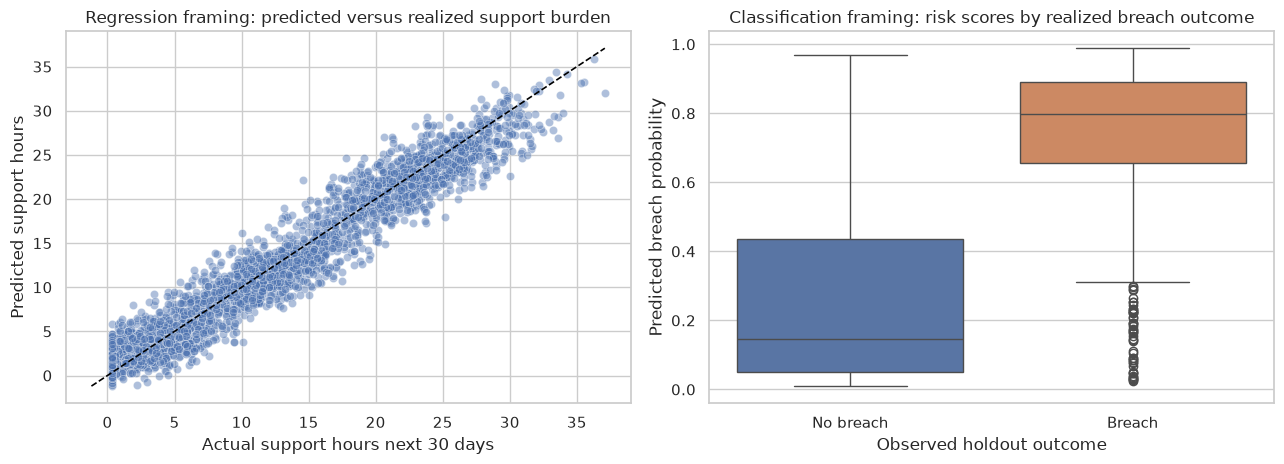

In [5]:
# Section focus: 4. Supervised Framing: Regression and Classification.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", make_one_hot_encoder()),
                ]
            ),
            categorical_features,
        ),
    ]
)

regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

classification_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=4000, class_weight="balanced")),
    ]
)

regression_model.fit(X_train, y_train_reg)
classification_model.fit(X_train, y_train_clf)

holdout = df.loc[test_mask, ["account_id", "month", "annual_revenue_k", "true_segment"]].copy()
holdout["actual_support_hours"] = y_test_reg.to_numpy()
holdout["predicted_support_hours"] = regression_model.predict(X_test)
holdout["actual_breach"] = y_test_clf.to_numpy()
holdout["predicted_breach_probability"] = classification_model.predict_proba(X_test)[:, 1]
holdout["predicted_breach_label_30pct"] = (holdout["predicted_breach_probability"] >= 0.30).astype(int)

performance_table = pd.DataFrame(
    [
        {
            "task": "Regression",
            "metric_1": "RMSE",
            "value_1": np.sqrt(mean_squared_error(holdout["actual_support_hours"], holdout["predicted_support_hours"])),
            "metric_2": "MAE",
            "value_2": mean_absolute_error(holdout["actual_support_hours"], holdout["predicted_support_hours"]),
        },
        {
            "task": "Classification",
            "metric_1": "ROC AUC",
            "value_1": roc_auc_score(holdout["actual_breach"], holdout["predicted_breach_probability"]),
            "metric_2": "PR AUC",
            "value_2": average_precision_score(holdout["actual_breach"], holdout["predicted_breach_probability"]),
        },
    ]
)

smart_display(performance_table.round(3))

plot_data = holdout.copy()
plot_data["actual_breach_label"] = plot_data["actual_breach"].map({0: "No breach", 1: "Breach"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.scatterplot(
    data=plot_data,
    x="actual_support_hours",
    y="predicted_support_hours",
    alpha=0.45,
    s=35,
    ax=axes[0],
)
line_min = min(plot_data["actual_support_hours"].min(), plot_data["predicted_support_hours"].min())
line_max = max(plot_data["actual_support_hours"].max(), plot_data["predicted_support_hours"].max())
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black", linewidth=1.2)
axes[0].set_title("Regression framing: predicted versus realized support burden")
axes[0].set_xlabel("Actual support hours next 30 days")
axes[0].set_ylabel("Predicted support hours")

sns.boxplot(
    data=plot_data,
    x="actual_breach_label",
    y="predicted_breach_probability",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[1],
)
axes[1].set_title("Classification framing: risk scores by realized breach outcome")
axes[1].set_xlabel("Observed holdout outcome")
axes[1].set_ylabel("Predicted breach probability")

plt.tight_layout()
plt.show()


Read Supervised Framing: Regression and Classification as a decision checkpoint. The pattern matters when it changes what the analyst models, inspects, thresholds, or governs.


### Discussion of Supervised Results

The regression and classification models are both useful, but they are useful in different ways.

The regression output is naturally aligned with **resource planning**. Even if the prediction is imperfect for any one account, it still helps leaders estimate queue pressure, budget staffing, and identify accounts likely to create unusually high service effort.

The classification output is naturally aligned with **risk management**. It does not tell us how many support hours will be consumed, but it does give a probability that can be thresholded, ranked, or combined with business value.

This is a good example of why framing and algorithm choice must be judged together. A single dataset can support multiple correct models, each correct relative to a different decision.


## 5. Ranking Under Capacity Constraints

Operational teams rarely act on every high-risk case. More often, they can review only the top 50, 100, or 500 units. That changes the modeling problem again.

A ranking problem asks: **if capacity is scarce, which score best concentrates the cases we care about near the top of the list?**


,priority_rule,selected_accounts,breach_rate_within_selected,breach_capture_share,support_hours_capture_share,revenue_at_risk_capture_share
0,Rank by breach probability,100,0.750000,0.172000,0.072000,0.146000
1,Rank by expected support hours,100,0.500000,0.114000,0.081000,0.183000
2,Rank by revenue-weighted risk,100,0.330000,0.076000,0.078000,0.172000


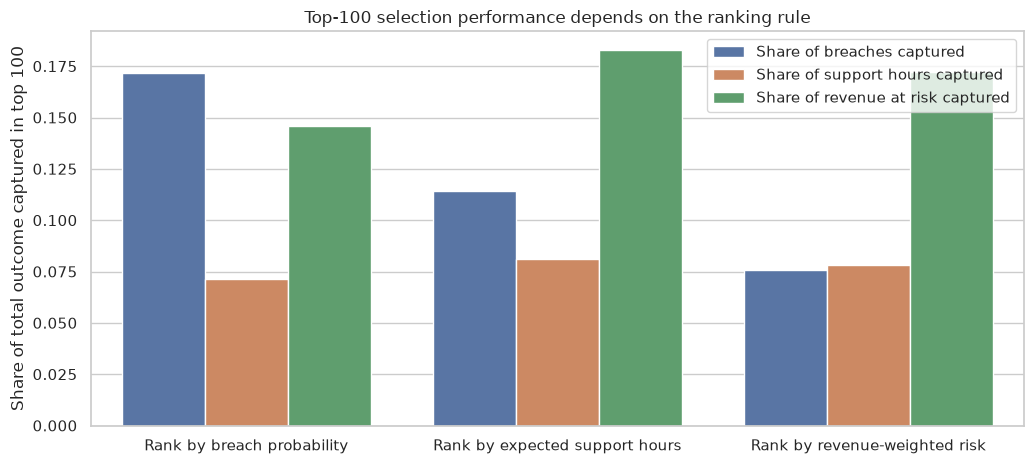

In [6]:
# Section focus: 5. Ranking Under Capacity Constraints.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

holdout["revenue_at_risk"] = holdout["annual_revenue_k"] * holdout["actual_breach"]
holdout["revenue_weighted_risk"] = holdout["annual_revenue_k"] * holdout["predicted_breach_probability"]

def evaluate_priority_rule(frame, score_column, rule_name, top_k=100):
    """Evaluate priority rule for the 02. Framing Business Questions as Supervised and Unsupervised Tasks decision workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    score_column : object
        Column or variable name used to select information from the input table.
    rule_name : object
        The rule name setting that controls the priority rule calculation in this notebook.
    top_k : object
        The top k setting that controls the priority rule calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    selected = frame.nlargest(top_k, score_column).copy()
    return {
        "priority_rule": rule_name,
        "selected_accounts": top_k,
        "breach_rate_within_selected": selected["actual_breach"].mean(),
        "breach_capture_share": selected["actual_breach"].sum() / frame["actual_breach"].sum(),
        "support_hours_capture_share": selected["actual_support_hours"].sum() / frame["actual_support_hours"].sum(),
        "revenue_at_risk_capture_share": selected["revenue_at_risk"].sum() / max(frame["revenue_at_risk"].sum(), 1e-9),
    }

priority_order = [
    "Rank by breach probability",
    "Rank by expected support hours",
    "Rank by revenue-weighted risk",
]
priority_results = pd.DataFrame(
    [
        evaluate_priority_rule(holdout, "predicted_breach_probability", "Rank by breach probability"),
        evaluate_priority_rule(holdout, "predicted_support_hours", "Rank by expected support hours"),
        evaluate_priority_rule(holdout, "revenue_weighted_risk", "Rank by revenue-weighted risk"),
    ]
)
priority_results["priority_rule"] = pd.Categorical(
    priority_results["priority_rule"],
    categories=priority_order,
    ordered=True,
)
priority_results = priority_results.sort_values("priority_rule")

smart_display(priority_results.round(3))

plot_priority = priority_results.melt(
    id_vars="priority_rule",
    value_vars=[
        "breach_capture_share",
        "support_hours_capture_share",
        "revenue_at_risk_capture_share",
    ],
    var_name="metric",
    value_name="share_captured",
)
plot_priority["metric"] = plot_priority["metric"].map(
    {
        "breach_capture_share": "Share of breaches captured",
        "support_hours_capture_share": "Share of support hours captured",
        "revenue_at_risk_capture_share": "Share of revenue at risk captured",
    }
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.barplot(
    data=plot_priority,
    x="priority_rule",
    y="share_captured",
    hue="metric",
    ax=ax,
)
ax.set_title("Top-100 selection performance depends on the ranking rule")
ax.set_xlabel("")
ax.set_ylabel("Share of total outcome captured in top 100")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")
plt.tight_layout()
plt.show()


These numbers translate model behavior into decision consequences. For Ranking Under Capacity Constraints, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


### Discussion of the Ranking Results

This comparison is where the framing lesson becomes especially concrete.

- Ranking by **breach probability** is designed to concentrate likely failures near the top.
- Ranking by **expected support hours** is better aligned with staffing or specialist time-allocation problems.
- Ranking by **revenue-weighted risk** shifts attention toward commercially important accounts, even if that is not the same as maximizing the raw number of failures caught.

In this particular run, ranking by **expected support hours** also captured the largest share of revenue at risk, which is a useful reminder that the empirically strongest rule is not always the one with the most obvious name.

Depending on the realized data and the weight placed on value versus volume, different ranking rules may dominate on different metrics. That is exactly the point. A score is only "best" relative to the operational objective it was built to support.


## 6. Unsupervised Framing: Segment Discovery for Operating Playbooks

Not every useful learning problem needs a label. Sometimes the organization wants structure, not a forecast.

Here the customer-success team may ask: **"What kinds of accounts do we really have, and should they receive different default workflows?"** That is an unsupervised question. Clustering does not predict the future outcome directly, but it can reveal heterogeneity that helps design differentiated policies.

As Jain (2010) emphasizes, clustering is not a single canonical answer machine. It is a structure-discovery tool whose value depends on whether the resulting groups are stable, interpretable, and operationally meaningful.


,operational_cluster,accounts,share_of_accounts,mean_support_hours,breach_rate,mean_revenue_k,mean_usage,mean_complexity,mean_training,dominant_hidden_segment
0,Cluster 1,331,0.348,3.010,0.012,56.347,0.693,2.183,0.640,Self-serve SMB
1,Cluster 2,311,0.327,12.523,0.055,129.785,0.985,4.446,0.539,Growth mid-market
2,Cluster 3,162,0.171,22.908,0.556,160.443,0.698,6.308,0.205,Distressed high-risk
3,Cluster 4,146,0.154,25.310,0.212,338.878,0.978,7.174,0.430,Complex enterprise


Silhouette score: 0.341


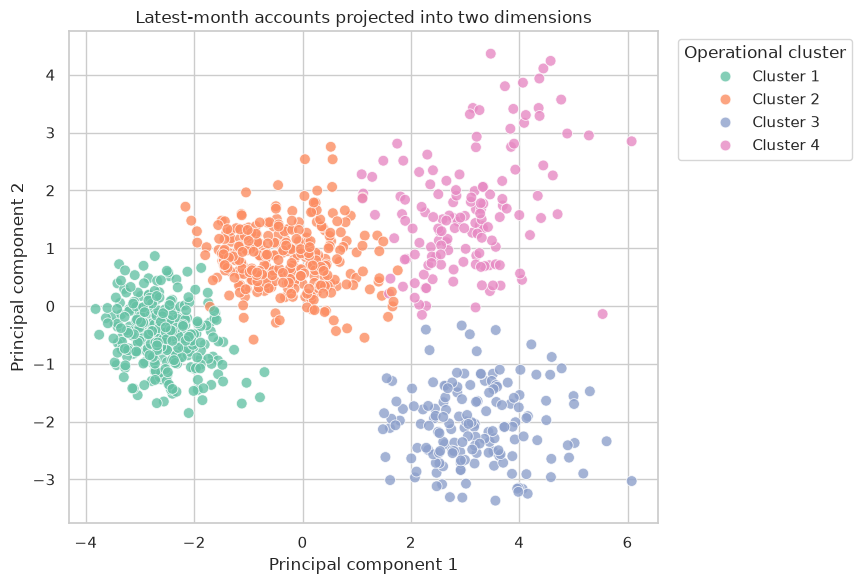

In [7]:
# Section focus: 6. Unsupervised Framing: Segment Discovery for Operating Playbooks.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

latest_snapshot = df.loc[df["month_index"] == df["month_index"].max()].copy()
cluster_features = [
    "annual_revenue_k",
    "seat_count",
    "usage_intensity",
    "integration_complexity",
    "training_completion_rate",
    "feature_adoption_rate",
    "nps",
    "prior_tickets_30d",
    "avg_response_minutes_last90d",
    "monthly_product_incidents",
    "unresolved_backlog",
]

cluster_matrix = StandardScaler().fit_transform(latest_snapshot[cluster_features])
kmeans = KMeans(n_clusters=4, n_init=20, random_state=2026)
latest_snapshot["cluster_raw"] = kmeans.fit_predict(cluster_matrix)

cluster_order = (
    latest_snapshot.groupby("cluster_raw")["support_hours_next_30d"]
    .mean()
    .sort_values()
    .index
)
cluster_labels = [f"Cluster {index + 1}" for index in range(len(cluster_order))]
cluster_map = {raw_label: cluster_labels[index] for index, raw_label in enumerate(cluster_order)}
latest_snapshot["operational_cluster"] = latest_snapshot["cluster_raw"].map(cluster_map)
latest_snapshot["operational_cluster"] = pd.Categorical(
    latest_snapshot["operational_cluster"],
    categories=cluster_labels,
    ordered=True,
)

embedding = PCA(n_components=2, random_state=2026).fit_transform(cluster_matrix)
latest_snapshot["pc1"] = embedding[:, 0]
latest_snapshot["pc2"] = embedding[:, 1]

cluster_profile = (
    latest_snapshot.groupby("operational_cluster", observed=True)
    .agg(
        accounts=("account_id", "size"),
        share_of_accounts=("account_id", lambda s: len(s) / len(latest_snapshot)),
        mean_support_hours=("support_hours_next_30d", "mean"),
        breach_rate=("sla_breach_next_30d", "mean"),
        mean_revenue_k=("annual_revenue_k", "mean"),
        mean_usage=("usage_intensity", "mean"),
        mean_complexity=("integration_complexity", "mean"),
        mean_training=("training_completion_rate", "mean"),
    )
    .reset_index()
)
cluster_lookup = latest_snapshot.groupby("operational_cluster", observed=True)["true_segment"].agg(modal_value)
cluster_profile["dominant_hidden_segment"] = cluster_profile["operational_cluster"].map(cluster_lookup)

smart_display(cluster_profile.round(3))
print(f"Silhouette score: {silhouette_score(cluster_matrix, latest_snapshot['cluster_raw']):.3f}")

fig, ax = plt.subplots(figsize=(8.8, 6.0))
sns.scatterplot(
    data=latest_snapshot,
    x="pc1",
    y="pc2",
    hue="operational_cluster",
    hue_order=cluster_labels,
    palette="Set2",
    s=60,
    alpha=0.80,
    ax=ax,
)
ax.set_title("Latest-month accounts projected into two dimensions")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.legend(title="Operational cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


The practical question in Unsupervised Framing: Segment Discovery for Operating Playbooks is simple. What would this result make the analyst do differently?


### Discussion of Unsupervised Results

The cluster table is valuable for a different reason than the supervised performance table.

We are not asking whether the cluster labels are "accurate" in the same sense as a classifier. Instead, we ask whether the discovered groups differ in ways that matter for operating policy. In this simulation they do: some clusters combine low burden and high training completion, while others combine high complexity, weak adoption, and much higher failure rates.

That makes clustering a useful framing when the organizational need is **playbook design** rather than **unit-level prediction**. For example, one cluster may deserve a largely digital self-serve workflow, while another may justify heavier implementation support and tighter monitoring.


## 7. Common Framing Failures and Better Redesigns

| Bad framing pattern | Why it fails | Better redesign |
|---|---|---|
| Predict a far-future outcome when decisions are made monthly | The label is too distant from the action window | Use a short, decision-relevant horizon such as next 30 days |
| Use variables that are only known after the intervention or outcome | This creates leakage and a false sense of model quality | Restrict features to information truly available at scoring time |
| Optimize generic accuracy for a rare-risk problem | Accuracy can reward ignoring the events that matter | Use probabilities, PR-style metrics, and top-$k$ capture logic |
| Cluster mixed historical states across incompatible time periods | The grouping becomes hard to interpret operationally | Cluster comparable snapshots taken at a common decision time |
| Treat ranking, classification, and regression as interchangeable | Each output supports a different action rule | Choose the formal task that matches the actual operational constraint |

These are usually **problem-definition mistakes** as well as modeling mistakes.


## 8. A Recommended Framing Memo for This Case

If we were advising the organization, a concise memo could read like this:

1. **Unit of analysis:** one account observed at the end of month $t$.
2. **Primary action horizon:** next 30 days.
3. **Regression task:** predict `support_hours_next_30d` to support staffing, budgeting, and workload planning.
4. **Classification task:** predict `sla_breach_next_30d` as a calibrated risk indicator for proactive outreach.
5. **Ranking task:** prioritize accounts using a score tied to scarce-capacity rules such as top-$k$ review or revenue-weighted protection.
6. **Unsupervised task:** cluster latest-month accounts to define differentiated default playbooks and escalation models.
7. **Validation principle:** preserve time order so training uses earlier months and the holdout uses later months.

That memo is already most of the analytical design. The algorithms come afterward.


## Wrap-Up

The core lesson of this notebook is simple but easy to forget: the same dataset can support multiple correct machine-learning tasks, and those tasks are not interchangeable.

For decision science, task framing is the bridge between business language and model language. Good analysts build that bridge explicitly. They specify the unit, the horizon, the action, the capacity constraint, and the loss implied by being wrong. Once that is done, supervised and unsupervised methods become tools in a coherent workflow rather than disconnected technical tricks.


## References

- Breiman, L. (2001). *Statistical Modeling: The Two Cultures (with comments and a rejoinder by the author).* *Statistical Science, 16*(3). [https://doi.org/10.1214/ss/1009213726](https://doi.org/10.1214/ss/1009213726)
- Bzdok, D., Altman, N., & Krzywinski, M. (2018). *Statistics versus machine learning.* [https://doi.org/10.1038/nmeth.4642](https://doi.org/10.1038/nmeth.4642)
- Domingos, P. (2012). *A few useful things to know about machine learning.* *Communications of the ACM, 55*(10), 78-87. [https://doi.org/10.1145/2347736.2347755](https://doi.org/10.1145/2347736.2347755)
- Hastie, T., Tibshirani, R., & Friedman, J. H. (2009). *The Elements of Statistical Learning.* Springer. [https://doi.org/10.1007/978-0-387-84858-7](https://doi.org/10.1007/978-0-387-84858-7)
- Jain, A. K. (2010). *Data clustering: 50 years beyond K-means.* *Pattern Recognition Letters, 31*(8), 651-666. [https://doi.org/10.1016/j.patrec.2009.09.011](https://doi.org/10.1016/j.patrec.2009.09.011)
- Van Calster, B., Verbakel, J. Y., Christodoulou, E., et al. (2019). *Statistics versus machine learning: definitions are interesting (but understanding, methodology, and reporting are more important).* *Journal of Clinical Epidemiology, 116*, 137-138. [https://doi.org/10.1016/j.jclinepi.2019.08.002](https://doi.org/10.1016/j.jclinepi.2019.08.002)
